In [ ]:
# Load dataset
import pandas as pd
youtubeDataKeywords = pd.read_csv("youtube_dataset_excerpt_nltk.csv")
youtubeDataKeywords.head()

,S No.,Link,Upload Date,Views,Likes,Comments,Transcript/Transcript Link,Excerpt,Excerpt_cleaned
0,1,https://www.youtube.com/watch?v=STt_SL87HLw,3/12/2023,800,42,15,https://tactiq.io/tools/run/youtube_transcript...,We here to get the bag and go home… I could te...,get bag go home could tell yall im tired getti...
1,2,https://www.youtube.com/watch?v=tgWkQC3_b30,5/31/2020,"1,000,000","23,000",8000,https://tactiq.io/tools/run/youtube_transcript...,"It’s half past midnight, I’m on my second brea...",half past midnight im second break really tire...
2,3,https://www.youtube.com/watch?v=GDu6cmst__A,3/1/2024,"28,000",500,50,https://tactiq.io/tools/run/youtube_transcript...,You’re going to come along with me working at ...,youre going come along working amazon hour shi...
3,4,https://www.youtube.com/watch?v=pqdzy0l0yRc,9/8/2022,"120,000","3,500",550,https://tactiq.io/tools/run/youtube_transcript...,Your first day you’re going to be sore… you’re...,first day youre going sore youre working hour ...
4,5,https://www.youtube.com/watch?v=Z6LBZoNx9bw,10/22/2025,"1,500",40,10,https://tactiq.io/tools/run/youtube_transcript...,Most workers do 10-hour shifts… it’s not the w...,workers hour shifts not work thats bad hours s...


In [ ]:
# Choose one column for keyword analysis
text_column = "Excerpt_cleaned"

In [ ]:
# Create custom stopword list
custom_stopwords = {
    # conversational filler
    "im", "ive", "youre", "yall", "yeah", "okay", "ok",
    "um", "uh", "like", "just", "really", "literally",
    "kind", "kinda", "sorta", "basically", "actually",
    "guys", "hey", "alright", "right", "so", "well",

    # low-value verbs
    "go", "going", "get", "got", "make", "made",
    "take", "takes", "put", "putting", "come",
    "came", "look", "looking", "see",

    # platform-obvious / redundant
    "amazon", "work", "working", "job",

    # social references
    "people", "person", "everyone",

    # transcript contractions/noise
    "dont", "didnt", "cant", "wont", "doesnt",
    "thats", "theres", "youll", "ill"
}

In [ ]:
# Download ntlk library
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Tokenize and count keywords
from collections import Counter

# Combine all text into one string
text_data = " ".join(youtubeDataKeywords[text_column].dropna()).lower()

# Create stopword set
from nltk.corpus import stopwords
nltk_stopwords = set(stopwords.words("english"))
all_stopwords = nltk_stopwords.union(custom_stopwords)

# Tokenize + filter immediately
import re
tokens = [
    word for word in re.sub(r"[^\w\s]", " ", text_data).split()
    if word not in all_stopwords and len(word) > 2 and not word.isdigit()
]

# Count frequency
word_counts = Counter(tokens)

# Top 20
top_20 = word_counts.most_common(20)
top_20

[('hour', 10),
 ('tired', 7),
 ('hours', 7),
 ('shift', 6),
 ('scan', 6),
 ('day', 5),
 ('bag', 3),
 ('home', 3),
 ('feet', 3),
 ('first', 3),
 ('shifts', 3),
 ('pretty', 3),
 ('boxes', 3),
 ('tell', 2),
 ('getting', 2),
 ('though', 2),
 ('four', 2),
 ('half', 2),
 ('past', 2),
 ('standing', 2)]

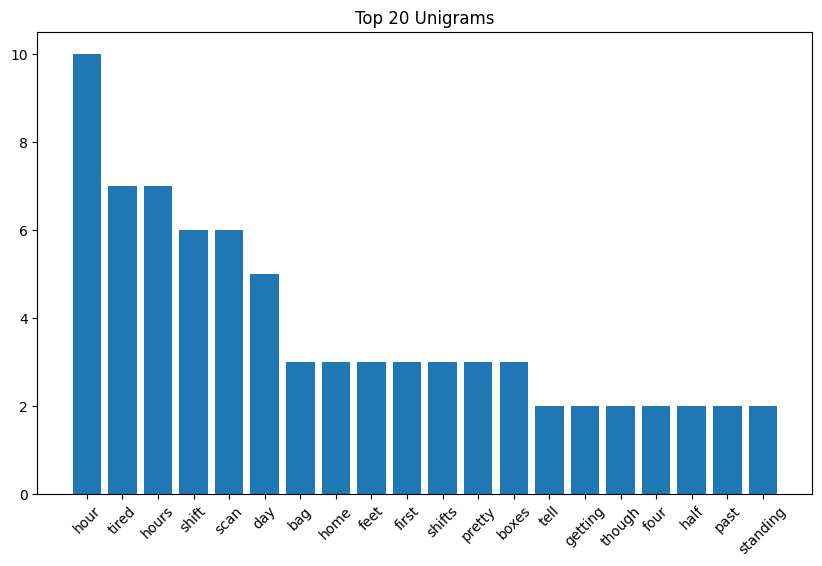

In [ ]:
# Unigram Visualization
import matplotlib.pyplot as plt

words, counts = zip(*top_20)

plt.figure(figsize=(10,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Unigrams")
plt.show()

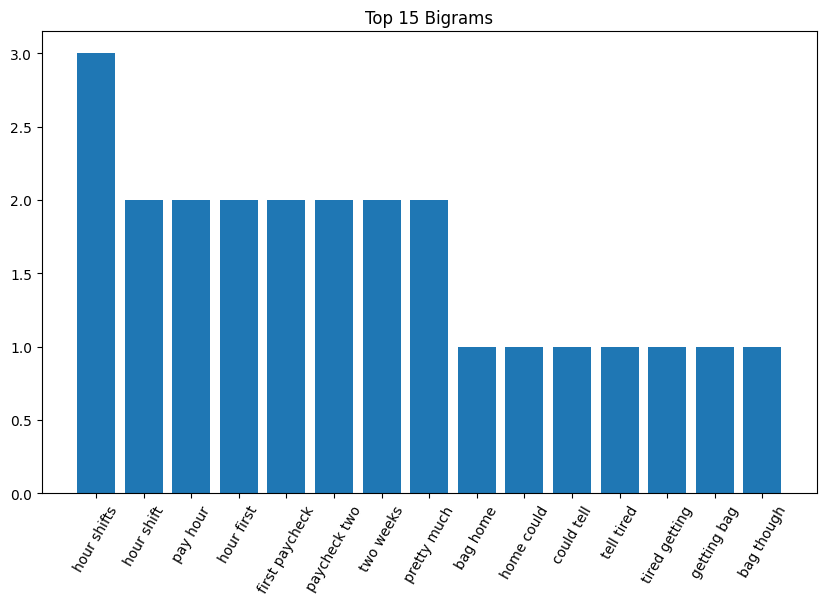

In [ ]:
# Bigram Visualization
from nltk import ngrams

bigrams = list(ngrams(tokens, 2))
bigram_counts = Counter(bigrams)

top_15_bigrams = bigram_counts.most_common(15)

bigram_labels = [" ".join(bg[0]) for bg in top_15_bigrams]
bigram_values = [bg[1] for bg in top_15_bigrams]

plt.figure(figsize=(10,6))
plt.bar(bigram_labels, bigram_values)
plt.xticks(rotation=60)
plt.title("Top 15 Bigrams")
plt.show()

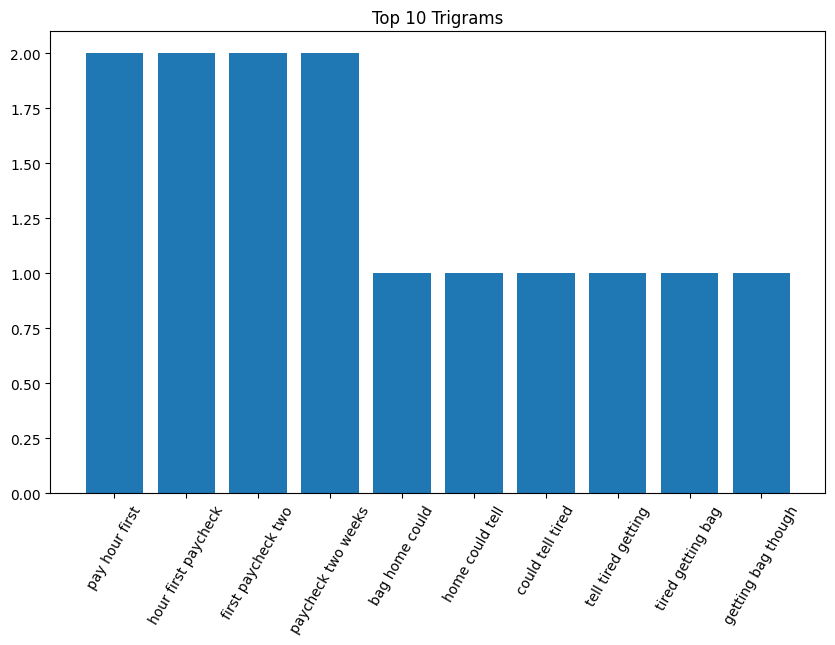

In [ ]:
# Trigram Visualization
trigrams = list(ngrams(tokens, 3))
trigram_counts = Counter(trigrams)

top_10_trigrams = trigram_counts.most_common(10)

trigram_labels = [" ".join(tg[0]) for tg in top_10_trigrams]
trigram_values = [tg[1] for tg in top_10_trigrams]

plt.figure(figsize=(10,6))
plt.bar(trigram_labels, trigram_values)
plt.xticks(rotation=60)
plt.title("Top 10 Trigrams")
plt.show()

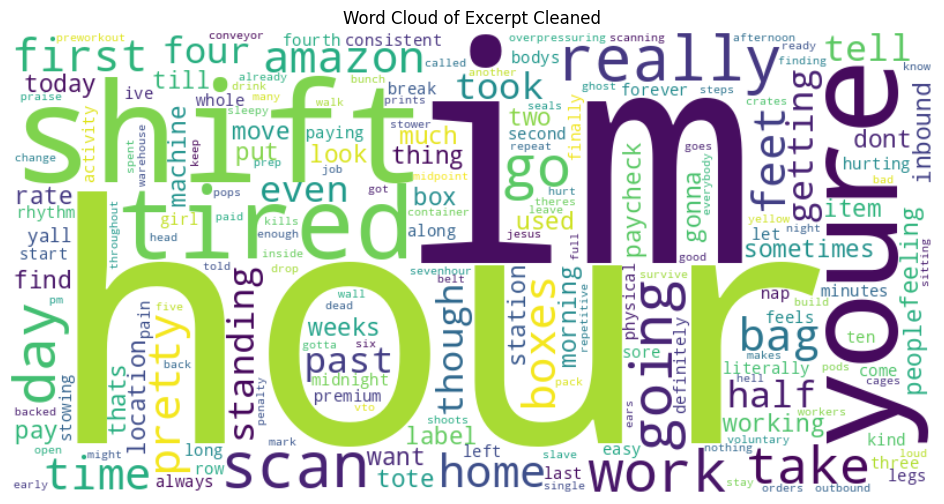

In [ ]:
# Word Cloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Excerpt Cleaned")
plt.show()